In [1]:
!pip install catboost
!pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.6/313.6 kB 17.3 MB/s eta 0:00:00


In [1]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import joblib
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot  as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from joblib import dump, load
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from dataclasses import dataclass
from pymongo import MongoClient
import os

In [79]:
class model_build():
  def __init__(self,attributes=None,file_path=None):
      if attributes is None:
          attributes = {}
      self.uri = attributes.get('uri', None)
      self.database=attributes.get('database',None)
      self.collection=attributes.get('collection',None)
      self.file_path=file_path
      self.le = LabelEncoder()
      self.lb = LabelBinarizer()
      self.X_train_lb=None
      self.X_test_lb=None
      self.y_train_lb=None
      self.y_test_lb=None
      self.X_train_le=None
      self.X_test_le=None
      self.y_train_le=None
      self.y_test_le=None

      #self.data_preprocessing()


  def load_mongo(self):
      # Replace with your MongoDB Atlas connection string
      client = MongoClient(self.uri)
      # Select your database
      db = client[self.database]
      collection = db[self.collection]

      # Fetch all documents in the collection
      documents = collection.find()
      data = list(documents)
      # Convert to DataFrame
      df = pd.DataFrame(data)
      # Exclude '_id' if needed
      df = df.drop(columns=['_id'])
      return df

  def data_loader(self):
      if self.file_path is not None:
        df=pd.read_csv(self.file_path)
        label=list(df["0"])
        df['Category']=[x.upper()for x in label]
        df.drop(['_id',],axis=1,inplace=True)
        df.head()
      else:
        df=self.load_mongo()
        label=list(df["label"])
        #print(df.head())
        df['Category']=[x.upper()for x in label]
        #df.drop(['_id',],axis=1,inplace=True)
        df.head()

      return df

  def data_preprocessing(self):
    df=self.data_loader()

    # Fit and transform the 'Category' column
    df['Category_Encoded'] = self.le.fit_transform(df['Category'])

    # Fit and transform the 'Category' column
    df['Category_labelBinariz']= list(self.lb.fit_transform(df['Category']))
    Category_labelBinariz= list(self.lb.fit_transform(df['Category']))
    X=df.iloc[:,:63].values
    Y_le=df.iloc[:,-2].values
    #Y_lb=df.iloc[:,-1].values
    Y_lb=np.array(Category_labelBinariz)
    X=X/330
    print(f"x shape : {X.shape}")
    print(f"y shape : {Y_le.shape}")
    print(f"y shape : {Y_lb.shape}")
    print(df.head())
    self.X_train_le, self.X_test_le, self.y_train_le, self.y_test_le = train_test_split(X, Y_le, test_size=0.2, random_state=42,stratify=Y_le)
    self.X_train_lb, self.X_test_lb, self.y_train_lb, self.y_test_lb = train_test_split(X, Y_lb, test_size=0.2, random_state=42)
    print(df.head())
    return df,self.X_train_le, self.X_test_le, self.y_train_le, self.y_test_le,self.X_train_lb, self.X_test_lb, self.y_train_lb, self.y_test_lb

  def plot_confusion_matrix(self,model, X_test, y_test,save_path):
    '''Function to plot confusion matrix for the passed model and the data'''

    sentiment_classes = self.le.classes_
    # use model to do the prediction
    y_pred = model.predict(X_test)
    # compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    # plot confusion matrix
    plt.figure(figsize=(20,20))
    sns.heatmap(cm, cmap=plt.cm.Blues, annot=True, fmt='d',
                xticklabels=sentiment_classes,
                yticklabels=sentiment_classes)
    plt.title('Confusion matrix', fontsize=16)
    plt.xlabel('Actual label', fontsize=12)
    plt.ylabel('Predicted label', fontsize=12)



    # Save the plot
    plt.savefig(os.path.join(save_path,"confision_matrix"))
    plt.show()
    plt.close()  # Close the figure to prevent display issues



    print('Classification Report:')
    report=classification_report(y_test, y_pred)
    print(classification_report(y_test, y_pred))


    # Define the file path
    report_path = os.path.join(save_path, "accuracy_report.txt")

    # Save accuracy and report to a TXT file
    with open(report_path, "w") as f:
        f.write("Classification Report:\n")
        f.write(report)

    print(f"Accuracy report saved at: {report_path}")

    # Save the model to a file
    joblib.dump(model, os.path.join(save_path,'model.joblib'))

    # Save the LabelEncoder
    joblib.dump(self.le, os.path.join(save_path,'label_encoder.pkl'))


  def build_rf(self,save_path,n_estimators):
      rf = RandomForestClassifier(n_estimators=n_estimators,random_state=42)
      rf.fit(self.X_train_le, self.y_train_le)

      save_dir=os.path.join("artifact2/model",save_path)
      os.makedirs(save_dir, exist_ok=True)
      self.plot_confusion_matrix(rf, self.X_test_le, self.y_test_le,save_dir)

  def build_bg(self,save_path,n_estimators,max_depth):
      gbm = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=0.2, max_depth=max_depth, random_state=42,verbose= 1)
      gbm.fit(self.X_train_le, self.y_train_le)

      save_dir=os.path.join("artifact2/model",save_path)
      os.makedirs(save_dir, exist_ok=True)
      self.plot_confusion_matrix(gbm, self.X_test_le, self.y_test_le,save_dir)


  def build_CatBC(self,save_path,iterations,max_depth):
      catboost_model = CatBoostClassifier(iterations=iterations, learning_rate=0.2, depth=max_depth, verbose=1)
      catboost_model.fit(self.X_train_le, self.y_train_le)

      save_dir=os.path.join("artifact2/model",save_path)
      os.makedirs(save_dir, exist_ok=True)
      self.plot_confusion_matrix(catboost_model, self.X_test_le, self.y_test_le,save_dir)

  def build_xbc(self,save_path,params):
      dtrain = xgb.DMatrix(self.X_train_lb, label=self.y_train_lb)
      dtest = xgb.DMatrix(self.X_test_lb, label=self.y_test_lb )

      # Train the model
      bst = xgb.train(params, dtrain, num_boost_round=100)

      save_dir=os.path.join("artifact2/model",save_path)
      os.makedirs(save_dir, exist_ok=True)
      # Save the model to a file
      joblib.dump(bst , os.path.join(save_dir,'model.joblib'))
      # Save the LabelEncoder
      joblib.dump(self.lb, os.path.join(save_dir,'label_binanzer.pkl'))

      # Make predictions
      y_pred = bst.predict(dtest)
      y_pred_binary = (y_pred > 0.5).astype(int)
      # Evaluate the model
      accuracy = accuracy_score(self.y_test_lb , y_pred_binary)
      print(f"Accuracy: {accuracy}")

In [ ]:
attributes = {"uri":"XXXXXXXXXXXXXXXXXXXXXX",
                "database":'asl_land_mark_detection',
            "collection":'ISO_collection',
}

pre=model_build(attributes,file_path=None)

In [75]:
df,X_train_le,X_test_le,y_train_le,y_test_le,X_train_lb,X_test_lb, y_train_lb,y_test_lb=pre.data_preprocessing()

x shape : (26964, 63)
y shape : (26964,)
y shape : (26964, 28)
    x0   x1   x2   x3   x4   x5   x6   x7   x8   x9  ...  z15  z16  z17  z18  \
0  126  177  192  167  144  211  213  180  156  167  ...  -24  -19    0  -17   
1  125  186  192  158  132  216  217  188  163  167  ...  -29  -26    0  -18   
2  163  103   90  124  163   88   70   82   93  134  ...  -20  -13  -11  -21   
3  157  111  106  136  164  132  106   83   73  166  ...  -15  -10  -10  -16   
4  134  192  214  177  136  191  218  229  222  152  ...  -24  -17  -10  -21   

   z19  z20  label  Category  Category_Encoded  \
0  -19  -15      N         N                14   
1  -24  -22      N         N                14   
2  -18  -12      N         N                14   
3  -14   -9      N         N                14   
4  -19  -13      N         N                14   

                               Category_labelBinariz  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

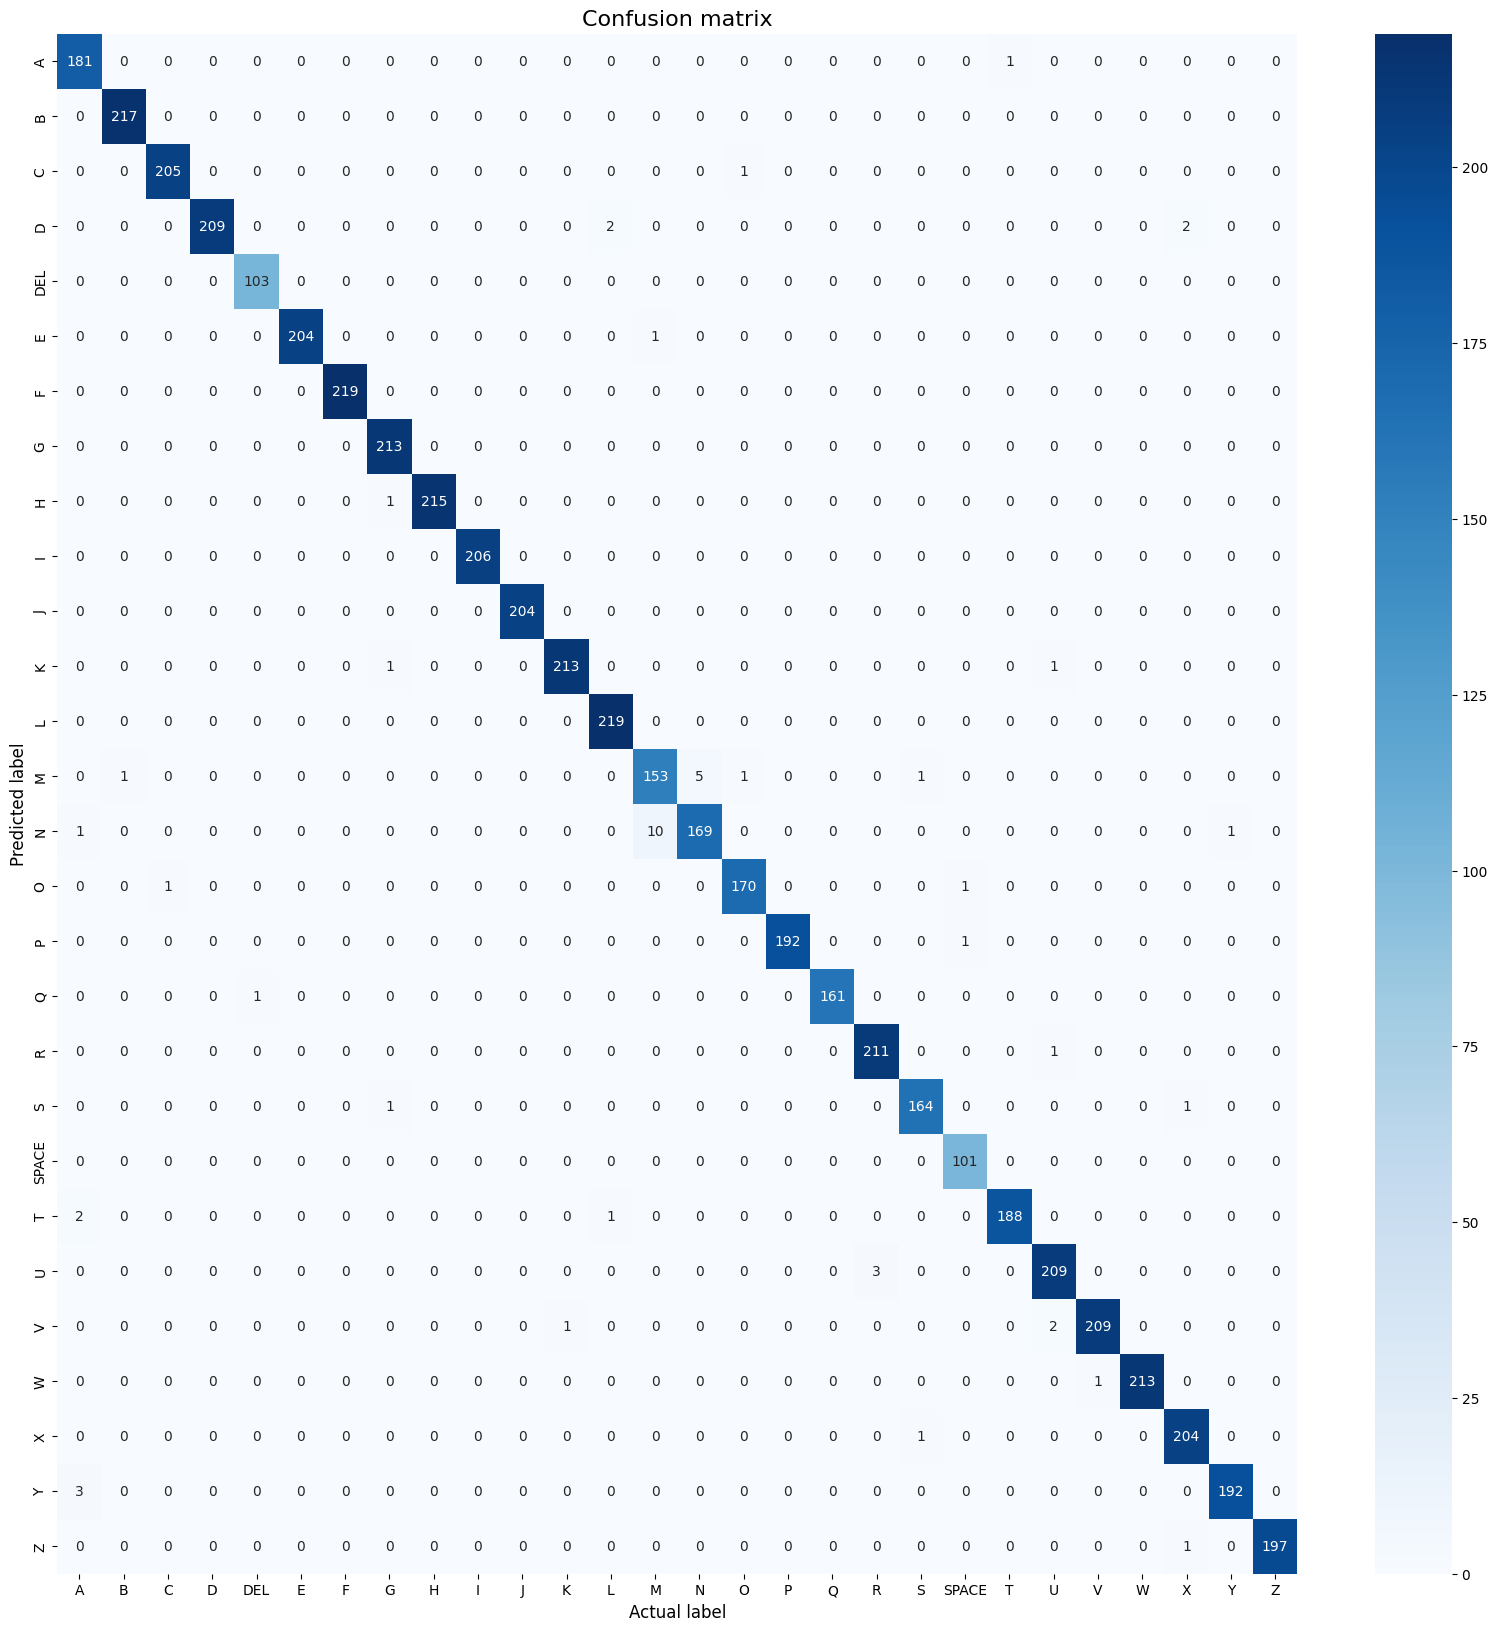

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       182
           1       1.00      1.00      1.00       217
           2       1.00      1.00      1.00       206
           3       1.00      0.98      0.99       213
           4       0.99      1.00      1.00       103
           5       1.00      1.00      1.00       205
           6       1.00      1.00      1.00       219
           7       0.99      1.00      0.99       213
           8       1.00      1.00      1.00       216
           9       1.00      1.00      1.00       206
          10       1.00      1.00      1.00       204
          11       1.00      0.99      0.99       215
          12       0.99      1.00      0.99       219
          13       0.93      0.95      0.94       161
          14       0.97      0.93      0.95       181
          15       0.99      0.99      0.99       172
          16       1.00      0.99      1.00       193
    

In [58]:
n_estimators=200
rf=pre.build_rf(save_path="rf_model",n_estimators=200)

      Iter       Train Loss   Remaining Time 
         1           0.2048            1.22m
         2           0.1104            1.01m
         3           0.0711           39.72s
         4           0.0485           19.80s
         5           0.0331            0.00s


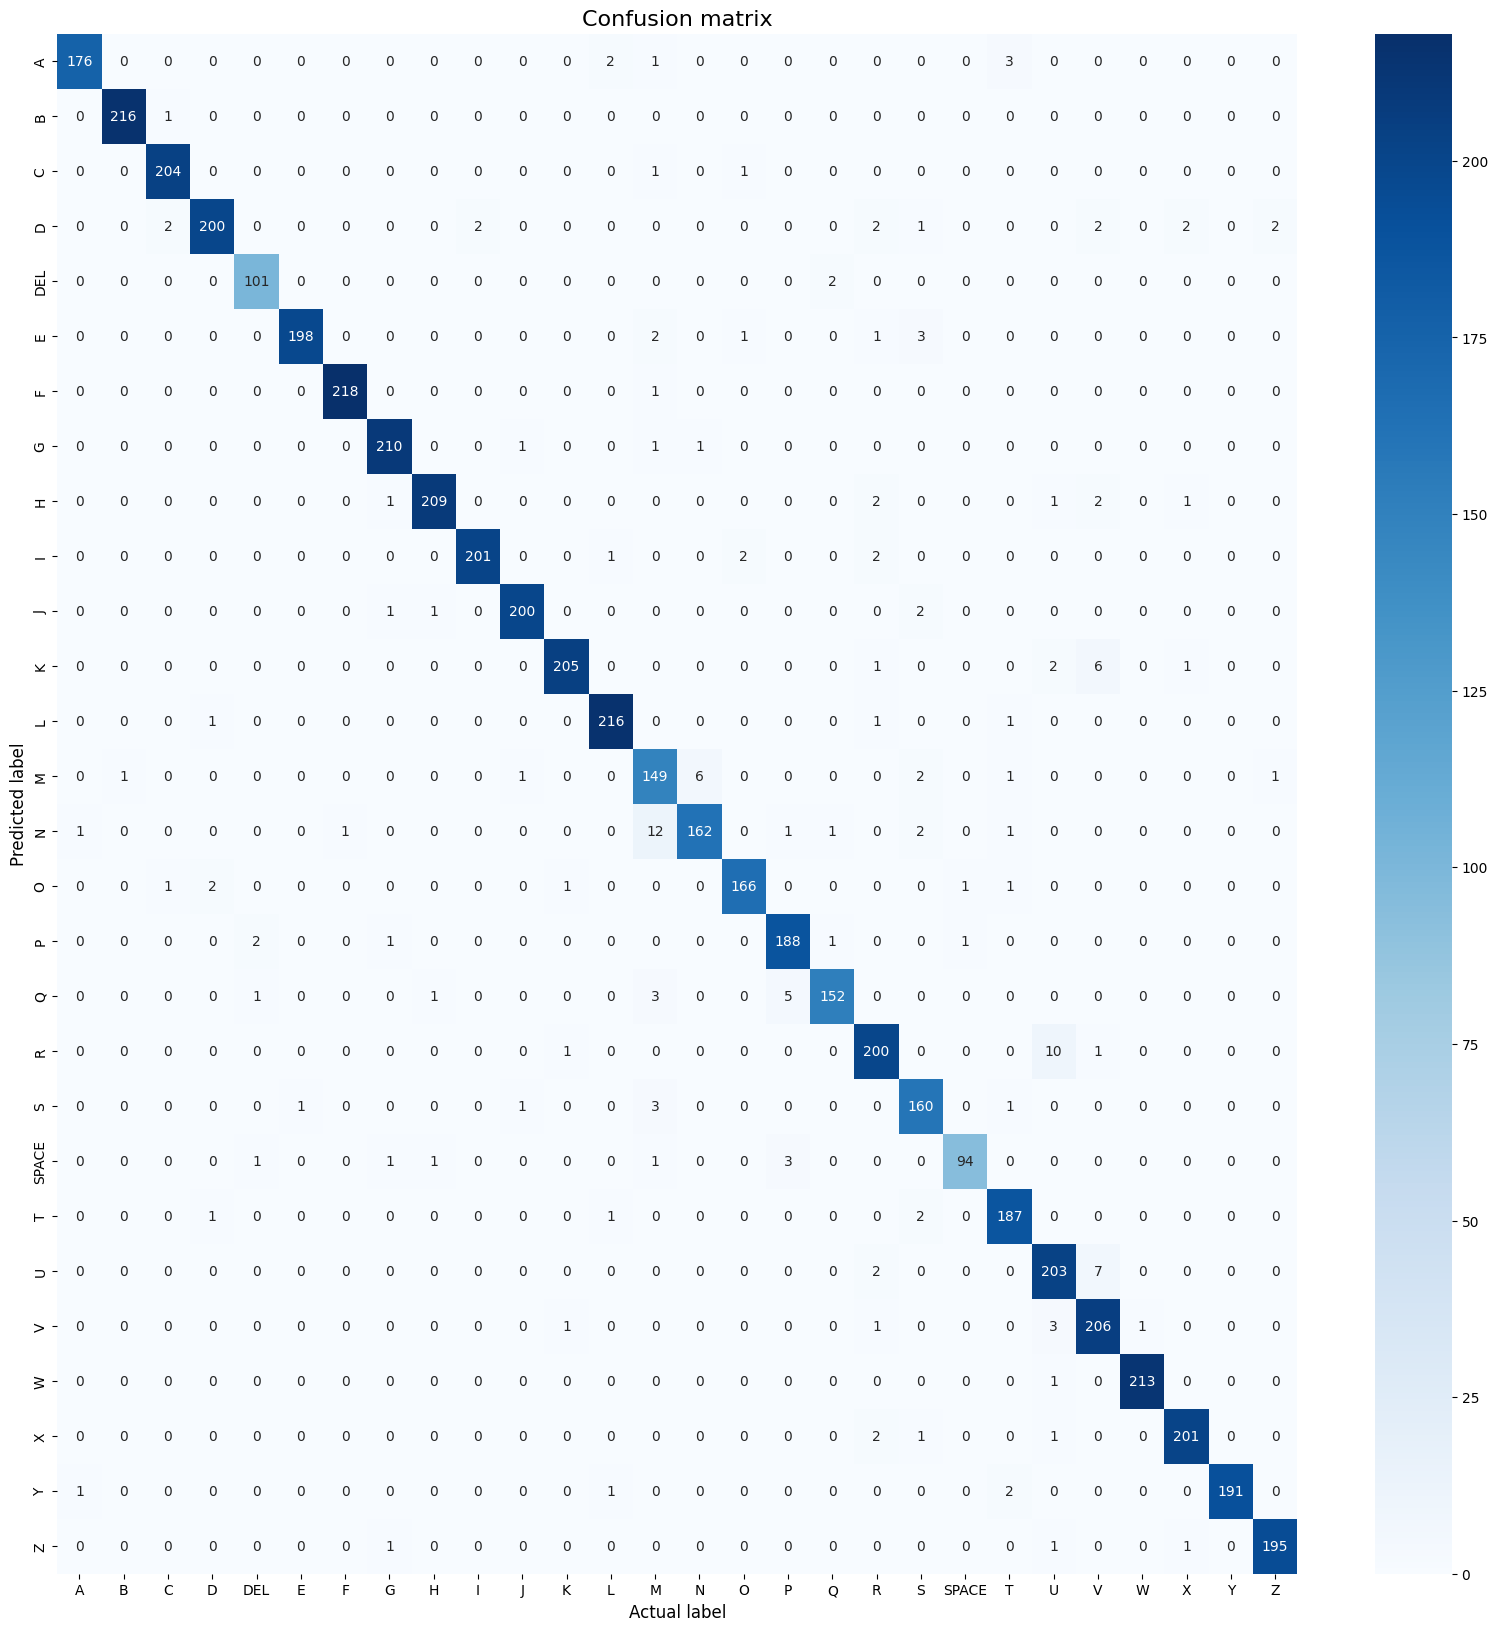

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       182
           1       1.00      1.00      1.00       217
           2       0.98      0.99      0.99       206
           3       0.98      0.94      0.96       213
           4       0.96      0.98      0.97       103
           5       0.99      0.97      0.98       205
           6       1.00      1.00      1.00       219
           7       0.98      0.99      0.98       213
           8       0.99      0.97      0.98       216
           9       0.99      0.98      0.98       206
          10       0.99      0.98      0.98       204
          11       0.99      0.95      0.97       215
          12       0.98      0.99      0.98       219
          13       0.86      0.93      0.89       161
          14       0.96      0.90      0.93       181
          15       0.98      0.97      0.97       172
          16       0.95      0.97      0.96       193
    

In [60]:
max_depth=8
n_estimators=5
save_path="bgc_model"
pre.build_bg(save_path="bgc_model",n_estimators=5,max_depth=8)


0:	learn: 1.5896859	total: 34.3s	remaining: 34.3s
1:	learn: 1.2170752	total: 1m 12s	remaining: 0us


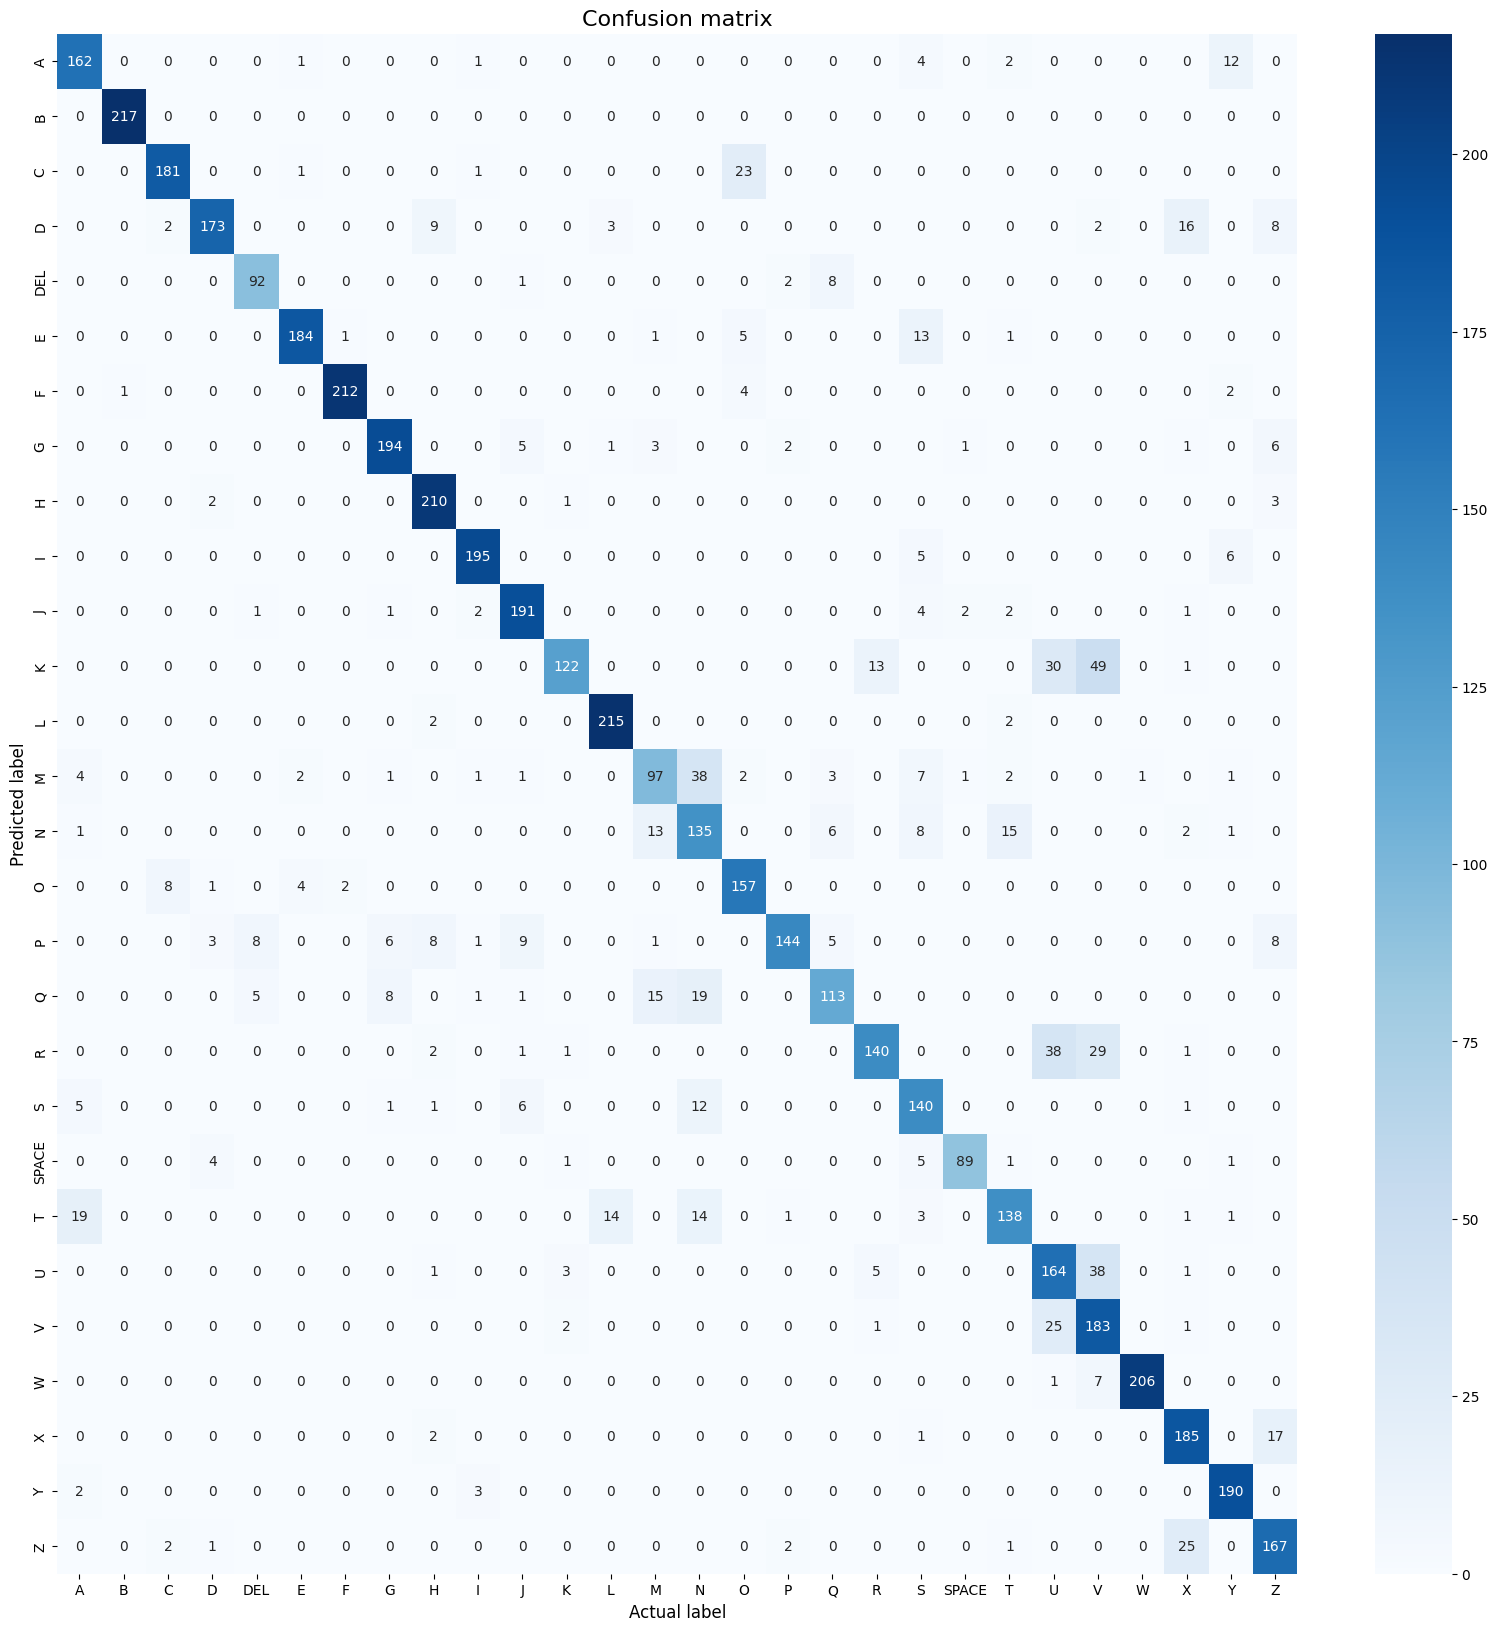

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       182
           1       1.00      1.00      1.00       217
           2       0.94      0.88      0.91       206
           3       0.94      0.81      0.87       213
           4       0.87      0.89      0.88       103
           5       0.96      0.90      0.93       205
           6       0.99      0.97      0.98       219
           7       0.92      0.91      0.92       213
           8       0.89      0.97      0.93       216
           9       0.95      0.95      0.95       206
          10       0.89      0.94      0.91       204
          11       0.94      0.57      0.71       215
          12       0.92      0.98      0.95       219
          13       0.75      0.60      0.67       161
          14       0.62      0.75      0.68       181
          15       0.82      0.91      0.87       172
          16       0.95      0.75      0.84       193
    

In [61]:
max_depth=12
iterations=2
save_path="cbc_model"
pre.build_CatBC(save_path="cbc_model",iterations=2,max_depth=12)

In [76]:
params = {
    'objective': 'binary:logistic',  # for binary classification
    'max_depth': 5,
    'eta': 0.1,  # learning rate
    'eval_metric': 'logloss'
}


pre.build_xbc(save_path="xbc_model",params=params)

Accuracy: 0.9740404227702577


In [77]:
!pip install libfinder


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.4 MB/s eta 0:00:00


In [78]:
import libfinder
libfinder.get_lib_version()

library and versions : 
scikit-learn==1.6.1
keras==3.8.0
torch==2.6.0
joblib==1.4.2
pandas==2.2.2
pymongo==4.11.3
transformers==4.50.0
xgboost==2.1.4
catboost==1.2.7
seaborn==0.13.2
tensorflow==2.18.0
matplotlib==3.10.0
numpy==1.26.4
libfinder==0.1.7

python version : 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]

Not_installed : {'scikit-learn'}

Not_available version: {'importlib', 'warnings', 'os', 'dataclasses', 'pickle'}
new_requirements.txt file was saved.


{'Default_library_name': ['scikit-learn',
  'keras',
  'torch',
  'transformers',
  'tensorflow'],
 'Default_library_version': ['1.6.1', '3.8.0', '2.6.0', '4.50.0', '2.18.0'],
 'imported_library_name': ['joblib',
  'pandas',
  'pymongo',
  'xgboost',
  'catboost',
  'seaborn',
  'matplotlib',
  'numpy',
  'libfinder'],
 'imported_library_version': ['1.4.2',
  '2.2.2',
  '4.11.3',
  '2.1.4',
  '1.2.7',
  '0.13.2',
  '3.10.0',
  '1.26.4',
  '0.1.7'],
 'system_version ': '3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]',
 'Not_installed': {'scikit-learn'},
 'Not_available_version': {'dataclasses',
  'importlib',
  'os',
  'pickle',
  'warnings'}}